In [ ]:
"""
================================================================================
TRACKING RESOLUTION CALCULATION BASED ON GLUCKSTERN EQUATIONS
================================================================================
This module implements charged particle track reconstruction error estimation
using the Gluckstern analytical formulas and their extensions.

Reference Papers:
1. Gluckstern (1963) - Original analytical formulas for track fitting errors
   https://doi.org/10.1016/0029-554X(63)90347-1

2. Extensions and refinements:
   - https://doi.org/10.1016/j.nima.2008.02.016
   - https://doi.org/10.1016/j.nima.2009.05.024
   - https://doi.org/10.1016/j.nima.2018.08.078

Software source: https://zenodo.org/records/11199209 (TrackingResolution-3.0)
Authors: Abbamonte, C., Cairo, V., Chen, F., Young, C. (2024)

PHYSICAL BASIS:
The code calculates the expected resolution (uncertainty) of charged particle
track parameters measured through a series of detector layers. The calculation
accounts for:
- Intrinsic detector resolution (from sensor measurements)
- Multiple scattering in detector materials
- Track geometry and lever arm effects
- Magnetic field effects on momentum resolution

The calculation is based on fitting a track to multiple measurements, using
covariance matrix formalism and matrix inversion to extract parameter errors.
================================================================================
"""

import numpy as np
from math import *
import argparse
import matplotlib.pyplot as plt
import copy
import argparse


class Layer:
    """
    Represents a single detector layer in the tracking system.
    
    This class encapsulates the properties of one measurement layer, including
    its material thickness (for multiple scattering), spatial resolution, and
    position along the beam direction.
    
    Attributes:
        d (float): Material thickness in radiation lengths (X0). 
                   Determines the strength of multiple scattering effects.
                   
        res_xy (float): Intrinsic resolution in the xy-plane (transverse to beam).
                        Represents the measurement uncertainty from the detector sensor.
                        
        res_z (float): Intrinsic resolution in the z-direction (along beam axis).
                       For cylindrical detectors, z typically refers to the axial direction.
                       
        position (float): Distance from the interaction point along the beam axis (in meters).
                         Used for track geometry calculations and lever arm effects.
                         
        ms (float): Multiple scattering contribution to the angular resolution.
                    Initially 0, calculated by msresolution() function.
                    Represents the scattering angle induced by Coulomb scattering.
    """
    def __init__(self, d, res_xy, res_z, position, ms=0):             
        self.d = d                      # width in radiation lengths (X0)            
        self.res_xy = res_xy            # detector resolution in transverse direction     
        self.res_z = res_z              # detector resolution in longitudinal direction (z)
        self.ms = ms                    # multiple scattering deviation (angular resolution)
        self.position = position        # position of the layer from interaction point


def beta(p, m):
    """
    Calculate the Lorentz beta factor (v/c) for a particle with given momentum.
    
    The beta factor is essential for multiple scattering calculations, as the
    scattering rate depends on particle velocity through the energy loss and
    interaction cross-section dependencies.
    
    Args:
        p (float): Momentum in GeV/c
        m (float): Particle mass in GeV/c²
        
    Returns:
        float: beta = v/c = p / sqrt(p² + m²)
        
    Physics:
        From relativistic mechanics: E² = (pc)² + (mc²)²
        beta = p/sqrt(p² + m²) (in natural units where c=1)
    """
    return p / sqrt(p*p + m*m)


def msresolution(l, p, m):
    """
    Calculate the multiple scattering contribution to angular resolution.
    
    Multiple scattering (MS) is the dominant source of momentum resolution at
    low momenta and a significant contributor at higher momenta. This function
    calculates the RMS scattering angle according to the Highland formula, which
    is an extension of the Gluckstern formalism.
    
    The scattering angle depends on:
    - Material thickness (d in X0)
    - Particle momentum and mass (through beta)
    - Logarithmic dependence on material thickness
    
    Args:
        l (Layer): Layer object to be updated with MS contribution
        p (float): Particle momentum in GeV/c
        m (float): Particle mass in GeV/c²
        
    Physics (Highland formula):
        θ_MS = (0.0136 GeV) / (β·p) · sqrt(d) · [1 + 0.038·ln(d)]
        
        where:
        - 0.0136 GeV is a constant from QED calculations
        - β = v/c (velocity relative to speed of light)
        - p = particle momentum
        - d = thickness in radiation lengths
        - The log term accounts for the angular dependence of scattering
        
    Reference:
        Highland, V. L. (1975). "Some practical remarks on multiple scattering"
        (embedded in Gluckstern extensions)
        
    Updates:
        l.ms: RMS scattering angle in radians
    """
    if l.d == 0:
        # No material = no scattering
        l.ms = 0
    else:
        # Highland formula for RMS scattering angle
        l.ms = 0.0136 / beta(p, m) / p * sqrt(l.d) * (1 + 0.038 * log(l.d))


def eta2sintheta(eta):
    """
    Convert pseudorapidity (η) to sin(θ), where θ is the polar angle.
    
    In high energy physics, pseudorapidity is used instead of polar angle
    because it simplifies Lorentz boost transformations. This function converts
    between the two parameterizations.
    
    Args:
        eta (float): Pseudorapidity (dimensionless)
        
    Returns:
        float: sin(θ) = 1/cosh(η)
        
    Physics:
        Pseudorapidity: η = -ln(tan(θ/2))
        
        Using the identity: cosh(η) = 1/sin(θ)
        Therefore: sin(θ) = 1/cosh(η)
        
        - η = 0 corresponds to θ = π/2 (perpendicular to beam, sin(θ) = 1)
        - η → ∞ corresponds to θ → 0 (along beam direction, sin(θ) → 0)
        
    Note:
        sin(θ) < 1 for all η, and this affects track geometry. Detectors at
        forward angles (large |η|) have different resolution characteristics
        because the track traverses the detector layers at a smaller angle to
        the radial direction.
    """
    return (1 / cosh(eta))


class Detector:
    """
    Represents the complete detector tracking system.
    
    This class manages a collection of detector layers and provides methods to:
    1. Build covariance matrices for measurements
    2. Fit tracks to the detector geometry
    3. Calculate the resulting parameter resolutions
    
    The core approach follows the Gluckstern formalism:
    - Build a covariance matrix from layer resolutions and MS contributions
    - Construct a track matrix (design matrix) based on layer positions
    - Use matrix inversion to extract parameter uncertainties
    
    The two track models implemented:
    1. Quadratic: y = a₀ + a₁·r + a₂·r²/2 (includes curvature, for curved tracks)
    2. Linear: y = a₀ + a₁·r (simplified, for approximately straight tracks)
    """
    
    def __init__(self):
        self.layers = []                # List of Layer objects    
        self.layerpositions = []        # Sorted list of layer positions
        self.N = 0                      # Number of layers
        
    def addlayer(self, d, res_xy, res_z, position):
        """
        Add a detector layer by specifying its properties directly.
        
        Args:
            d (float): Thickness in radiation lengths
            res_xy (float): Resolution in xy-plane
            res_z (float): Resolution in z-direction
            position (float): Distance from interaction point
            
        Raises:
            ValueError: If attempting to add two layers at the same position
        """
        if position in self.layerpositions:
            raise ValueError("Cannot add two layer at the same position")
        l = Layer(d, res_xy, res_z, position)
        self.layerpositions.append(position)
        self.layerpositions.sort()
        self.layers.insert(self.layerpositions.index(position), l)
        self.N += 1

    def addlayer2(self, l):
        """
        Add a detector layer by passing a Layer object.
        
        Useful for adding pre-configured layers or copying layer properties.
        
        Args:
            l (Layer): Layer object to add
            
        Raises:
            ValueError: If attempting to add two layers at the same position
        """
        position = l.position
        if position in self.layerpositions:
            raise ValueError("Cannot add two layer at the same position")
        self.layerpositions.append(position)
        self.layerpositions.sort()
        self.layers.insert(self.layerpositions.index(position), l)
        self.N += 1

    def track(self):
        """
        Build the track design matrix for quadratic track fitting.
        
        This matrix relates the 3 track parameters (a₀, a₁, a₂) to 
        measurements at each layer. Used for curved track fitting.
        
        Track equation: y(r) = a₀ + a₁·r + a₂·r²/2
        where:
        - a₀: intercept (impact parameter in xy-plane or z-position)
        - a₁: slope (angle or direction)
        - a₂: curvature (related to 1/pT in a magnetic field)
        
        Returns:
            np.array: 3×N matrix where:
            - Row 0: [1, 1, ..., 1] (constant term coefficient)
            - Row 1: [r₁, r₂, ..., rₙ] (linear term, layer positions)
            - Row 2: [r₁²/2, r₂²/2, ..., rₙ²/2] (quadratic term)
            
        This matrix A is used in the calculation: θ_param = (A·C⁻¹·Aᵀ)⁻¹
        where C is the covariance matrix of measurements.
        """
        a1 = [1 for i in range(self.N)]
        a2 = [self.layerpositions[i] for i in range(self.N)]
        a3 = [self.layerpositions[i] * self.layerpositions[i] / 2 for i in range(self.N)]
        return np.array((a1, a2, a3))

    def track_linear(self):
        """
        Build the track design matrix for linear track fitting.
        
        For simplified analysis or forward angles, a linear approximation
        may be sufficient: y(r) = a₀ + a₁·r
        
        Parameters:
        - a₀: impact parameter / z-position
        - a₁: track slope / angle
        
        Returns:
            np.array: 2×N matrix where:
            - Row 0: [1, 1, ..., 1] (constant term)
            - Row 1: [r₁, r₂, ..., rₙ] (linear term, positions)
        """
        a1 = [1 for i in range(self.N)]
        a2 = [self.layerpositions[i] for i in range(self.N)]
        return np.array((a1, a2))

    def covariancey_xy(self):
        """
        Build the measurement covariance matrix for transverse (xy) direction.
        
        This matrix encodes the correlations and uncertainties in measurements
        in the plane perpendicular to the beam. Each element (i,j) represents
        the covariance between measurements at layers i and j.
        
        The covariance has two contributions:
        
        1. DIAGONAL TERM (i=j):
           Measurement resolution: C_ii = (res_xy[i])²
           Only the measurement at layer i contributes.
           
        2. OFF-DIAGONAL TERM (i≠j, specifically i>j):
           Multiple scattering coupling: 
           C_ij += Σ_k [MS_k² × (r_i - r_k) × (r_j - r_k)]
           where sum is over all layers k upstream of both i and j.
           
           Physical meaning: MS at layer k affects measurements at all
           downstream layers i,j similarly, creating positive covariance.
        
        Returns:
            np.ndarray: N×N covariance matrix (symmetric)
            
        Physics:
            From Gluckstern: the total measurement uncertainty combines
            - Intrinsic detector resolution
            - Multiple scattering angle uncertainty (Highland formula)
              projected onto measurement positions
        """
        t1 = []
        for i in range(self.N):
            t2 = []
            for j in range(self.N):
                Cyij = 0.0
                # Diagonal: intrinsic measurement resolution
                if i == j:
                    Cyij += self.layers[i].res_xy * self.layers[i].res_xy
                # Off-diagonal: multiple scattering contributions from upstream layers
                for k in range(min([i, j])):
                    # MS at layer k creates correlated uncertainties at layers i,j
                    Cyij += self.layers[k].ms * self.layers[k].ms * \
                            (self.layerpositions[i] - self.layerpositions[k]) * \
                            (self.layerpositions[j] - self.layerpositions[k])
                t2.append(Cyij)
            t1.append(t2)
        return np.array(t1)
    
    def covariancey_z(self):
        """
        Build the measurement covariance matrix for longitudinal (z) direction.
        
        Similar to covariancey_xy() but for the z-direction (along beam axis).
        Uses the same mathematical structure but with res_z instead of res_xy.
        
        In cylindrical detectors:
        - xy-plane: transverse to beam (perpendicular layers measure this)
        - z-direction: along beam axis (barrel detectors measure this)
        
        Returns:
            np.ndarray: N×N covariance matrix (symmetric)
        """
        t1 = []
        for i in range(self.N):
            t2 = []
            for j in range(self.N):
                Cyij = 0.0
                # Diagonal: intrinsic measurement resolution in z
                if i == j:
                    Cyij += self.layers[i].res_z * self.layers[i].res_z
                # Off-diagonal: multiple scattering contributions
                for k in range(min([i, j])):
                    Cyij += self.layers[k].ms * self.layers[k].ms * \
                            (self.layerpositions[i] - self.layerpositions[k]) * \
                            (self.layerpositions[j] - self.layerpositions[k])
                t2.append(Cyij)
            t1.append(t2)
        return np.array(t1)

    def covariancey_z_1(self):
        """
        Compute the inverse of the z-direction covariance matrix.
        
        Used in least-squares fitting: the weight matrix W = C⁻¹ gives
        higher weights to more precise measurements.
        
        Returns:
            np.ndarray: Inverse of the covariance matrix
        """
        covy = self.covariancey_z()
        return np.linalg.inv(covy)

    def covariancey_xy_1(self):
        """
        Compute the inverse of the xy-direction covariance matrix.
        
        Used in least-squares fitting for transverse direction.
        
        Returns:
            np.ndarray: Inverse of the covariance matrix
        """
        covy = self.covariancey_xy()
        return np.linalg.inv(covy)
    
    def error_z(self):
        """
        Calculate parameter errors for quadratic fitting in z-direction.
        
        Implements the Gluckstern formula for track fitting errors:
        Σ_param = (A × C⁻¹ × Aᵀ)⁻¹
        
        where:
        - A: design matrix (track parameterization)
        - C⁻¹: inverse measurement covariance matrix (weight matrix)
        - Σ_param: covariance matrix of fitted parameters
        
        Returns:
            np.ndarray: 3×3 parameter covariance matrix containing:
            - [0,0]: variance of a₀ (impact parameter / z-position)
            - [1,1]: variance of a₁ (slope)
            - [2,2]: variance of a₂ (curvature)
            
        The diagonal elements are σ² for each parameter.
        
        Physics:
            This is the inverse of the Fisher information matrix.
            The lever arm effects are encoded: parameters estimated at
            large distances from the layer clusters have better resolution.
        """
        def covariancea():
            t = np.dot(self.track(), self.covariancey_z_1())
            t = np.dot(t, self.track().transpose())
            t = np.linalg.inv(t)
            return t       
        return covariancea()

    def error_xy(self):
        """
        Calculate parameter errors for quadratic fitting in xy-direction.
        
        Implements the Gluckstern formula for transverse track fitting.
        See error_z() for physics explanation.
        
        Returns:
            np.ndarray: 3×3 parameter covariance matrix
        """
        t = np.dot(self.track(), self.covariancey_xy_1())
        t = np.dot(t, self.track().transpose())
        t = np.linalg.inv(t)
        return t       
    
    def error_linear_z(self):
        """
        Calculate parameter errors for linear fitting in z-direction.
        
        Simpler fit using only 2 parameters: a₀ + a₁·r
        Returns 2×2 covariance matrix.
        """
        t = np.dot(self.track_linear(), self.covariancey_z_1())
        t = np.dot(t, self.track_linear().transpose())
        t = np.linalg.inv(t)
        return t    

    def error_linear_xy(self):
        """
        Calculate parameter errors for linear fitting in xy-direction.
        
        Simpler fit using only 2 parameters.
        Returns 2×2 covariance matrix.
        """
        t = np.dot(self.track_linear(), self.covariancey_xy_1())
        t = np.dot(t, self.track_linear().transpose())
        t = np.linalg.inv(t)
        return t    
    
    
    #### MAIN LOGIC FUNCTION ####
    def errorcalculation(self, p, B, eta=0, m=0.106):
        """
        Calculate track parameter resolution as a function of physics parameters.
        
        This is the main calculation method that connects detector configuration
        to physics observables. It accounts for:
        - Magnetic field effects on momentum resolution
        - Pseudorapidity (forward angles) effects on geometry
        - Multiple scattering at the given momentum
        
        Args:
            p (float): Transverse momentum p_T in GeV/c
                      (or momentum p for non-cylindrical detectors)
                      
            B (float): Magnetic field strength in Tesla
                      Used to convert curvature parameter to momentum
                      
            eta (float): Pseudorapidity (default: 0, perpendicular to beam)
                        Accounts for forward angle track geometry
                        
            m (float): Particle mass in GeV/c² (default: 0.106, muon mass)
                      Used for beta calculation in multiple scattering
        
        Returns:
            dict: Tracking resolution parameters:
            - 'sigma(pt)/pt': Relative momentum resolution
            - 'sigma(d)': Impact parameter resolution [μm]
            - 'sigma(phi)': Azimuthal angle resolution [radians]
            - 'sigma(z)': Z-position resolution [μm]
            - 'sigma(theta)': Polar angle resolution [radians]
        
        Calculation Steps:
        1. Convert pseudorapidity to get sin(θ) for forward angle correction
        2. Create a temporary detector with rescaled positions/thicknesses
           accounting for the track angle relative to detector radius
        3. Update all multiple scattering contributions with p/sin(θ)
           (momentum perpendicular to detector scales up at forward angles)
        4. Fit quadratic track in xy-plane for pT resolution
        5. Fit linear track in z-direction for z and θ resolution
        6. Apply coordinate and field transformations to convert to physics units
        
        Physics Details:
        
        IMPACT PARAMETER (sigma(d)):
        - Extracted from covariance matrix element [0,0]
        - Multiplied by 1e6 to convert to μm
        
        AZIMUTHAL ANGLE (sigma(phi)):
        - From element [1,1], represents angle in xy-plane
        - Scaled by 1/sin(θ) to account for forward angle
        
        TRANSVERSE MOMENTUM (sigma(pt)/pt):
        - From element [2,2], the curvature covariance
        - Conversion: p_T = 0.3 × B × r_curv (standard high-energy formula)
        - Therefore: σ(p_T) = √C[2,2] × 0.3 × B × (dp_T/dr)
        - Relative resolution: σ(p_T)/p_T = √C[2,2] × p / (0.3 × B)
        - Sin(θ)² factor accounts for transverse-only resolution
        
        LONGITUDINAL POSITION (sigma(z)):
        - From linear fit in z-direction, element [0,0]
        - Multiplied by 1e6 for μm, scaled by 1/sin(θ)
        
        POLAR ANGLE (sigma(theta)):
        - From linear fit element [1,1]
        - RMS scattering angle in z-direction
        
        TODO notes in original code indicate unclear factors:
        - Why the 1e6 factor in impact parameter?
        - Why additional factors in pT resolution formula?
        These may represent detector-specific calibrations or
        coordinate system transformations not fully documented.
        """
        error = dict()
        sintheta = eta2sintheta(eta)
        
        # Create temporary detector with forward-angle corrected geometry
        tempd = Detector()
        for i in range(self.N):
            # Copy layer and scale for track angle
            l = copy.deepcopy(self.layers[i])
            l.d = l.d / sintheta              # Material thickness increases at forward angles
            l.position = l.position / sintheta  # Effective spacing increases
            # Recalculate multiple scattering with forward-angle corrected momentum
            msresolution(l, p / sintheta, m)  # p → p/sin(θ) because only transverse part
            tempd.addlayer2(l)
        
        # Fit transverse (xy) track
        ca = tempd.error_xy()
        ca_linear = tempd.error_linear_xy()
        
        # Extract transverse parameters
        # NOTE: The 1e6 factor and trigonometric scaling need clarification
        # These may be detector-specific normalizations
        error['sigma(pt)/pt'] = sqrt(ca[2][2]) * p / 0.3 / B * (1/sintheta) * (1/sintheta)
        error['sigma(d)'] = sqrt(ca[0][0]) * 1e6   # TODO: why * 1e6?
        error['sigma(phi)'] = sqrt(ca[1][1]) / sintheta
        
        # Fit longitudinal (z) track, accounting for rescaled z-resolution
        for i in range(self.N):
            tempd.layers[i].res_z = tempd.layers[i].res_z * sintheta  # Undo the scaling
        
        ca = tempd.error_z()
        ca_linear = tempd.error_linear_z()
        
        # Extract longitudinal parameters
        error['sigma(z)'] = sqrt(ca_linear[0][0]) * 1e6 / sintheta
        error['sigma(theta)'] = sqrt(ca_linear[1][1])
        
        return error
    

# ============================================================================
# EXAMPLE DETECTOR CONFIGURATIONS
# ============================================================================

def ATLAS():
    """
    ATLAS Inner Detector configuration (simplified).
    
    The ATLAS detector at the LHC has a cylindrical tracker with:
    - Innermost: Pixel detector (precise but few layers)
    - Outer: Semiconductor tracker / Strip detector (larger radius)
    
    This represents Layer 0 (ATLAS upgrade ITk reference design).
    """
    Pixel1 = Layer(0.0067, 5.0e-5/sqrt(12), 5.0e-5/sqrt(12), 0.039)
    Pixel2 = Layer(0.0067, 5.0e-5/sqrt(12), 5.0e-5/sqrt(12), 0.099)
    Pixel3 = Layer(0.0067, 5.0e-5/sqrt(12), 5.0e-5/sqrt(12), 0.16)
    Pixel4 = Layer(0.0067, 5.0e-5/sqrt(12), 5.0e-5/sqrt(12), 0.22)
    Pixel5 = Layer(0.0067, 5.0e-5/sqrt(12), 5.0e-5/sqrt(12), 0.279)
    Strip1 = Layer(0.02, 7.575e-5/sqrt(12), 7.575e-5/sqrt(12), 0.405)
    Strip2 = Layer(0.02, 7.575e-5/sqrt(12), 7.575e-5/sqrt(12), 0.562)
    Strip3 = Layer(0.02, 7.575e-5/sqrt(12), 7.575e-5/sqrt(12), 0.762)
    Strip4 = Layer(0.02, 7.575e-5/sqrt(12), 7.575e-5/sqrt(12), 1)
    detector = Detector()
    detector.addlayer2(Pixel1)
    detector.addlayer2(Pixel2)
    detector.addlayer2(Pixel3)
    detector.addlayer2(Pixel4)
    detector.addlayer2(Pixel5)
    detector.addlayer2(Strip1)
    detector.addlayer2(Strip2)
    detector.addlayer2(Strip3)
    detector.addlayer2(Strip4)
    return detector

def Validation1():
    """
    Test configuration: No material, only measurement resolution.
    
    Used to validate the code: with no multiple scattering (d=0),
    only measurement resolution should contribute to track errors.
    This provides a baseline for comparing different detectors.
    """
    Pixel1 = Layer(0, 1e-6, 1e-6, 0.1)
    Pixel2 = Layer(0, 1e-6, 1e-6, 0.2)
    Pixel3 = Layer(0, 1e-6, 1e-6, 0.3)
    Pixel4 = Layer(0, 1e-6, 1e-6, 0.4)
    Pixel5 = Layer(0, 1e-6, 1e-6, 0.5)
    detector = Detector()
    detector.addlayer2(Pixel1)
    detector.addlayer2(Pixel2)
    detector.addlayer2(Pixel3)
    detector.addlayer2(Pixel4)
    detector.addlayer2(Pixel5)
    return detector

def Validation2():
    """
    Test configuration: High material, minimal measurement resolution.
    
    Used to validate multiple scattering calculations. With thick material
    (d=0.1 X₀) and very fine resolution (1e-8), MS should dominate.
    """
    Pixel1 = Layer(0.1, 1e-8, 1e-8, 0.1)
    Pixel2 = Layer(0.1, 1e-8, 1e-8, 0.2)
    Pixel3 = Layer(0.1, 1e-8, 1e-8, 0.3)
    Pixel4 = Layer(0.1, 1e-8, 1e-8, 0.4)
    Pixel5 = Layer(0.1, 1e-8, 1e-8, 0.5)
    detector = Detector()
    detector.addlayer2(Pixel5)
    detector.addlayer2(Pixel4)
    detector.addlayer2(Pixel3)
    detector.addlayer2(Pixel2)
    detector.addlayer2(Pixel1)
    return detector


###### INPUT PROCESSING FUNCTIONS #######

def inputfromfile(filename, verbose):
    """
    Read detector configuration from a text file.
    
    File Format (one layer per line):
    width(X0)  resolution_xy  resolution_z  position(m)
    
    Example:
    0.0067   5.0e-5    5.0e-5    0.039
    0.02     7.5e-5    7.5e-5    0.405
    
    Args:
        filename (str): Path to configuration file
        verbose (bool or int): If truthy, print layer information
        
    Returns:
        Detector: Configured detector object, or None on error
    """
    if filename == None:
        return None
    
    userdetector = Detector()
    
    # Validate verbose flag
    if verbose != None:
        try:
            float(verbose)
            if float(verbose) > 1:
                print("Error: verbose number must be either 1 or 0" % verbose)
                return None
        except:
            print("Error: Cannot resolve -verbose %s. It must be a number!" % verbose)
            return None
    
    # Check file exists
    try:
        f = open(filename, 'r')
        f.close()
    except:
        print("Error: Cannot open file from %s" % filename)
        return None
    
    # Parse file
    with open(filename, 'r') as f: 
        if verbose:
            print("#\tWidth\tResolutionxy\tResolutionz\tposition")
        
        lines = f.readlines()
        count = 0
        # Filter: only lines with exactly 4 space-separated values, not comments
        lines = [line for line in lines if len(line.split()) == 4 and line.split()[0][0] != '#']
        
        for line in lines:
            try:
                tempt = [float(num) for num in line.split()]
            except:
                print("Error: The input file is not supported, please check that the file is in required format.")
                return None
            
            count += 1
            d, resolutionxy, resolutionz, position = [float(num) for num in line.split()]
            userdetector.addlayer(d, resolutionxy, resolutionz, position)
            
            if verbose:
                print('%-3d\t%.5g\t%.5g\t\t%.5g\t\t%.5g' % (count, d, resolutionxy, resolutionz, position))
    
    if count == 0:
        print("Error: The input file is not supported or empty, please check that the file is in required format.")
        return None
    
    print("Successfully read %d layers" % count)
    return userdetector


def addparser():
    """
    Build command-line argument parser for detector analysis.
    
    Returns list of parsed values: [detector, momentum, B_field, pseudorapidity, mass]
    """
    parser = argparse.ArgumentParser(
        description='Detector resolution calculation.\nWritten by Feng Chen'
    )
    parser.add_argument('-f', '--foo', help='input file at F00')
    parser.add_argument('-m', '--m', help='mass of the particle in GeV/c^2 (default: muon mass)', 
                       default=0.106)
    parser.add_argument('-B', '--B', help='magnetic field in T (default: 2T)', default=2)
    parser.add_argument('-eta', '--eta', help='pseudorapidity (default: 0)', default=0)
    parser.add_argument('-p', '--p', help='momentum of the particle in GeV/c (default: 1 GeV)', 
                       default=1)
    parser.add_argument('-verbose', '--verbose', 
                       help='set to 1 to print the input layer configuration (default: 0)', 
                       default=0)
    args = parser.parse_args() 
    return [inputfromfile(args.foo, args.verbose), args.p, args.B, args.eta, args.m]


#########################################

def calculation():
    """
    Main calculation routine: parse arguments, load detector, compute resolution.
    """
    detector, p, B, eta, m = addparser()
    
    if detector != None:
        # Validate and convert arguments
        try:
            p = float(p)
        except:
            print("Error: Cannot resolve -p %s. It must be a number!" % p)
            return
        try:
            B = float(B)
        except:
            print("Error: Cannot resolve -B %s. It must be a number!" % B)
            return
        try:
            m = float(m)
        except:
            print("Error: Cannot resolve -m %s. It must be a number!" % m)
            return
        try:
            eta = float(eta)
        except:
            print("Error: Cannot resolve -eta %s. It must be a number!" % eta)
            return
        
        # Calculate and display results
        error = detector.errorcalculation(p, B, eta, m)
        for quantity in error.keys():
            print(quantity + '=%.4g' % error[quantity])
        return 1
    else:
        print('No detector is selected.')


def main():
    """Entry point for script execution."""
    print("load successfully")
    calculation()


if __name__ == "__main__":
    main()


load successfully
Error: The input file is not supported or empty, please check that the file is in required format.
No detector is selected.


In [ ]:
# Plot is a function of the file input, the error variable (i.e. 'sigma(d)'), and the B field (default = 2T).

def plot_fixedeta(filename,var,B=2,eta=0,m=0.106):
    mydetector = inputfromfile(filename, 1)
    p = np.logspace(-0.1,2.1)
    y = []
    for i in range(len(p)):
        y.append(mydetector.errorcalculation(p[i], B, eta, m)[var])
    print(y[0])
    plt.xscale('log')
    plt.plot(p,y,label="Calculation")   # NOTE change label to reflect the physical meaning
                                        # better in case of multiple plots
    plt.legend()
    ylabel=var
    if var == 'sigma(d)' or var == 'sigma(z)' :
        ylabel = ylabel + ' [$\mu m$]'
    elif var == 'sigma(phi)' or var == 'sigma(theta)' :
        ylabel = ylabel + ' [radians]'
    plt.ylabel(ylabel)
    plt.xlabel('pT [GeV]')
    
    return mydetector

def plot_fixedp(filename,var,B=2,p=1,m=0.106):
    mydetector = inputfromfile(filename, 1)
    eta = np.linspace(0, 2.5, 100)
    y = []
    for i in range(len(eta)):
        y.append(mydetector.errorcalculation(p,B,eta[i],m)[var])
    print(y[0])
    plt.plot(eta,y,label="Calculation")  # NOTE change label to reflect the physical meaning
                                         # better in case of multiple plots
    plt.legend()
    ylabel=var
    if var == 'sigma(d)' or var == 'sigma(z)' :
        ylabel = ylabel + ' [$\mu m$]'
    elif var == 'sigma(phi)' or var == 'sigma(theta)' :
        ylabel = ylabel + ' [radians]'
    plt.ylabel(ylabel)
    plt.xlabel('$\eta$')
    
    return mydetector

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\e'
/var/folders/06/4mfw39l90p15785y1mn_4fsh0000gn/T/ipykernel_1207/1184928290.py:16: SyntaxWarning: invalid escape sequence '\m'
  ylabel = ylabel + ' [$\mu m$]'
/var/folders/06/4mfw39l90p15785y1mn_4fsh0000gn/T/ipykernel_1207/1184928290.py:36: SyntaxWarning: invalid escape sequence '\m'
  ylabel = ylabel + ' [$\mu m$]'
/var/folders/06/4mfw39l90p15785y1mn_4fsh0000gn/T/ipykernel_1207/1184928290.py:40: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta$')


#	Width	Resolutionxy	Resolutionz	position
1  	0.0174	1.43e-05		1.43e-05		0.039
2  	0.0174	1.43e-05		1.43e-05		0.099
3  	0.0174	1.43e-05		1.43e-05		0.16
4  	0.0174	1.43e-05		1.43e-05		0.228
5  	0.0174	1.43e-05		1.43e-05		0.291
6  	0.0505	2.19e-05		2.19e-05		0.399
7  	0.0505	2.19e-05		2.19e-05		0.562
8  	0.0505	2.19e-05		2.19e-05		0.762
9  	0.0505	2.19e-05		2.19e-05		1
Successfully read 9 layers
81.1142240927586


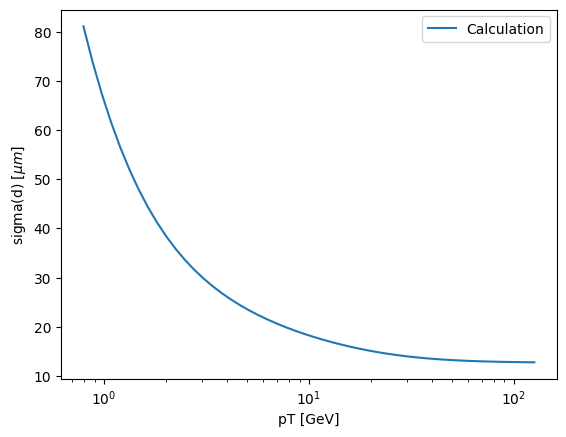

In [28]:
plot_fixedeta('ATLAS.txt','sigma(d)')

#	Width	Resolutionxy	Resolutionz	position
1  	0.0174	1.43e-05		1.43e-05		0.039
2  	0.0174	1.43e-05		1.43e-05		0.099
3  	0.0174	1.43e-05		1.43e-05		0.16
4  	0.0174	1.43e-05		1.43e-05		0.228
5  	0.0174	1.43e-05		1.43e-05		0.291
6  	0.0505	2.19e-05		2.19e-05		0.399
7  	0.0505	2.19e-05		2.19e-05		0.562
8  	0.0505	2.19e-05		2.19e-05		0.762
9  	0.0505	2.19e-05		2.19e-05		1
Successfully read 9 layers
65.99283286102256


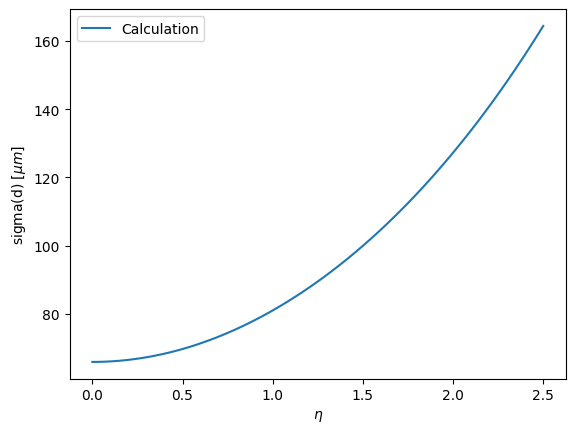

In [29]:
plot_fixedp('ATLAS.txt','sigma(d)')

#	Width	Resolutionxy	Resolutionz	position
1  	0.0174	1.43e-05		1.43e-05		0.039
2  	0.0174	1.43e-05		1.43e-05		0.099
3  	0.0174	1.43e-05		1.43e-05		0.16
4  	0.0174	1.43e-05		1.43e-05		0.228
5  	0.0174	1.43e-05		1.43e-05		0.291
6  	0.0505	2.19e-05		2.19e-05		0.399
7  	0.0505	2.19e-05		2.19e-05		0.562
8  	0.0505	2.19e-05		2.19e-05		0.762
9  	0.0505	2.19e-05		2.19e-05		1
Successfully read 9 layers
64.40468549922197


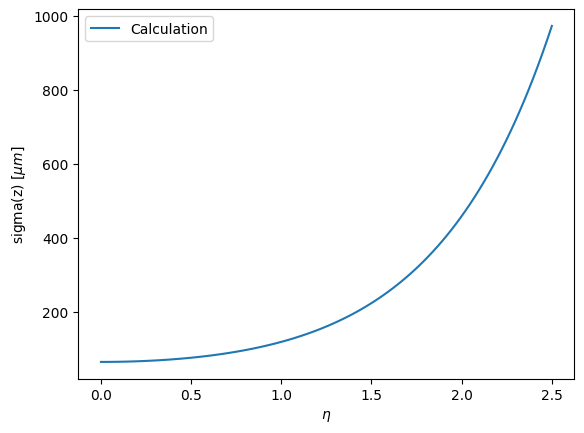

In [30]:
plot_fixedp('ATLAS.txt','sigma(z)')